# F1 Machine Learning Pipeline - Clean Version

This notebook provides a cleaned and refactored version of the F1 ML pipeline with:
- Modular functions with clear responsibilities
- Comprehensive docstrings and inline comments
- Reduced code redundancy
- Better code organization and maintainability

## Section 1: Import Required Libraries

In [230]:
import os
import logging
import math
from pathlib import Path
from dotenv import load_dotenv
from supabase import create_client, Client

# Import data manipulation libraries
import pandas as pd
import numpy as np
import logging

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn utilities
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    accuracy_score,
    average_precision_score,
    mean_absolute_error, 
    mean_squared_error
)

# Import machine learning and hyperparameter optimization
import xgboost as xgb
import optuna
from optuna.logging import set_verbosity


# configure logging to mimic the previous print statements. this ensures all
# informational messages are captured consistently and can be directed to
# stdout or a file if desired in the future. use the same format used by the ETL
# runner for consistency.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s - %(message)s"
)

# confirm successful imports via logging
logging.info("All libraries imported successfully!")

2026-03-04 12:38:48,686 [INFO] root - All libraries imported successfully!


In [231]:


logger = logging.getLogger(__name__)

# read the .env file to add values into os.environ
# __file__ isn’t defined in the notebook, so fall back to cwd
env_path = Path.cwd() / ".env"
load_dotenv(dotenv_path=env_path)

# List of F1 tables to pull from Supabase
# These correspond to the tables loaded in the ETL pipeline
TABLES = [
    "circuits",
    "constructors",
    "constructor_standings",
    "drivers",
    "driver_standings",
    "qualifying",
    "races",
    "results",
    "to_predict"
]


def get_supabase_client() -> Client:
    """
    Read credentials from environment and return supabase client.
    
    This function loads Supabase URL and API key from the .env file
    to establish a connection to the database. Raises an error if
    credentials are missing.
    """
    url: str = os.getenv("SUPABASE_URL")
    key: str = os.getenv("SUPABASE_KEY")

    if not url or not key:
        raise EnvironmentError("SUPABASE_URL and SUPABASE_KEY must be set in your .env file.")
    logger.info("Connecting to Supabase...")
    return create_client(url, key)


def _fetch_all_data(client: Client, table_name: str) -> list[dict]:
    """
    Fetch all data from a Supabase table by paginating through results.
    
    Supabase limits queries to 1000 rows by default. This function uses
    the range() method to fetch data in batches of 1000 rows until all
    data is retrieved. This ensures we get complete datasets even for
    large tables like 'qualifying' and 'results'.
    
    Args:
        client: Supabase client instance
        table_name: Name of the table to fetch data from
        
    Returns:
        List of dictionaries representing all rows in the table
    """
    all_data = []
    offset = 0
    batch_size = 1000

    while True:
        # Fetch a batch of up to 1000 rows starting from the current offset
        response = client.table(table_name).select("*").range(offset, offset + batch_size - 1).execute()
        data = response.data
        if not data:
            break
        all_data.extend(data)
        # If we got fewer than batch_size rows, we've reached the end
        if len(data) < batch_size:
            break
        offset += batch_size

    return all_data


def pull_all_tables(client: Client | None = None) -> dict[str, pd.DataFrame]:
    """
    Pull all F1 tables from Supabase, convert to DataFrames, and return as a dictionary.
    
    This is the main function that orchestrates pulling data from all tables.
    It uses pandas DataFrames for easy data manipulation and analysis.
    If no client is provided, it creates one using environment credentials.
    
    Args:
        client: Optional Supabase client. If None, creates a new one.
        
    Returns:
        Dictionary with table names as keys and pandas DataFrames as values
    """
    if client is None:
        client = get_supabase_client()

    dataframes = {}

    for table_name in TABLES:
        logger.info(f"Pulling '{table_name}'...")
        # Fetch complete data using pagination
        data = _fetch_all_data(client, table_name)
        # Convert to pandas DataFrame for easy analysis
        df = pd.DataFrame(data)
        dataframes[table_name] = df
        logger.info(f"Pulled '{table_name}' with {len(df)} rows")

    logger.info("Pull complete")
    return dataframes

## Section 2: Define Data Loading Functions

In [232]:


def load_all_tables():
    """
    Load all F1 race-related tables from the data source.
    
    Returns:
        dict: Dictionary containing DataFrames with keys:
            - 'circuits': Circuit information
            - 'constructors': Constructor/team information
            - 'constructor_standings': Constructor championship standings
            - 'drivers': Driver information
            - 'driver_standings': Driver championship standings
            - 'qualifying': Qualifying session results
            - 'races': Race information and dates
            - 'results': Race results and points
    """
    dataframes = pull_all_tables()
    
    # Provide a brief summary of the shapes of each table
    logging.info("Data Loading Summary:")
    logging.info("-" * 50)
    for name, df in dataframes.items():
        logging.info(f"  {name:30s} Shape: {df.shape}")
    logging.info("-" * 50)
    
    return dataframes


def prepare_results_base(results):
    """
    Prepare the base results DataFrame by sorting by driver, season, and round.
    
    Args:
        results (pd.DataFrame): Raw results DataFrame
        
    Returns:
        pd.DataFrame: Sorted results DataFrame
    """
    # sort without modifying the original DataFrame in place
    results = results.sort_values(['driver_id', 'season', 'round'], inplace=False)
    logging.info(f"Results sorted: {results.shape[0]} records")
    return results


# Load data from source and unpack into individual DataFrames
# These variables are used throughout subsequent processing steps

dataframes = load_all_tables()

# Extract individual tables
circuits = dataframes['circuits']
constructors = dataframes['constructors']
constructor_standings = dataframes['constructor_standings']
drivers = dataframes['drivers']
driver_standings = dataframes['driver_standings']
qualifying = dataframes['qualifying']
races = dataframes['races']
results = dataframes['results']

# initial preparation on the results table
results = prepare_results_base(results)

2026-03-04 12:38:48,711 [INFO] __main__ - Connecting to Supabase...
2026-03-04 12:38:48,921 [INFO] __main__ - Pulling 'circuits'...
2026-03-04 12:38:49,318 [INFO] httpx - HTTP Request: GET https://inispwtbhamelhtpoics.supabase.co/rest/v1/circuits?select=%2A&offset=0&limit=1000 "HTTP/2 200 OK"
2026-03-04 12:38:49,323 [INFO] __main__ - Pulled 'circuits' with 76 rows
2026-03-04 12:38:49,323 [INFO] __main__ - Pulling 'constructors'...
2026-03-04 12:38:49,385 [INFO] httpx - HTTP Request: GET https://inispwtbhamelhtpoics.supabase.co/rest/v1/constructors?select=%2A&offset=0&limit=1000 "HTTP/2 200 OK"
2026-03-04 12:38:49,391 [INFO] __main__ - Pulled 'constructors' with 168 rows
2026-03-04 12:38:49,391 [INFO] __main__ - Pulling 'constructor_standings'...
2026-03-04 12:38:49,455 [INFO] httpx - HTTP Request: GET https://inispwtbhamelhtpoics.supabase.co/rest/v1/constructor_standings?select=%2A&offset=0&limit=1000 "HTTP/2 200 OK"
2026-03-04 12:38:49,458 [INFO] __main__ - Pulled 'constructor_standin

## Section 3: Define Feature Engineering Functions

In [233]:
# Define DNF (Did Not Finish) keywords for pattern matching
DNF_KEYWORDS = [
    'retired', 'accident', 'collision', 'disqualified',
    'engine', 'gearbox', 'hydraulics', 'suspension', 'brakes',
    'electrical', 'electronics', 'power', 'ers', 'turbo',
    'transmission', 'fuel', 'oil', 'overheating', 'water',
    'driveshaft', 'cooling', 'mechanical', 'wheel', 'puncture',
    'spun', 'withdrew', 'damage', 'vibrations'
]
DNF_PATTERN = '|'.join(DNF_KEYWORDS)


def engineer_performance_features(results):
    """
    Engineer performance-based features from raw results.
    
    Features created:
    - avg_last_5: Rolling average of points from last 5 races (per driver)
    - dnf: Binary indicator (1 if DNF, 0 if finished)
    - dnf_rate_5: Rolling average DNF rate over last 5 races (per driver)
    
    Args:
        results (pd.DataFrame): Results DataFrame with 'points' and 'status' columns
        
    Returns:
        pd.DataFrame: Results DataFrame with engineered features
    """
    results = results.copy()
    
    # Create rolling average of points over last 5 races
    # shift(1) ensures we use only past data to avoid data leakage
    results['avg_last_5'] = (
        results.groupby('driver_id')['points']
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )
    
    # Create binary DNF indicator based on status keywords
    results['dnf'] = (
        results['status']
        .str.contains(DNF_PATTERN, case=False, na=False)
        .astype(int)
    )
    
    # Create rolling average of DNF rate over last 5 races
    results['dnf_rate_5'] = (
        results.groupby('driver_id')['dnf']
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )
    
    logging.info("Performance features engineered:")
    logging.info("  - avg_last_5 (rolling points average)")
    logging.info("  - dnf (binary DNF indicator)")
    logging.info("  - dnf_rate_5 (rolling DNF rate)")
    
    return results


def merge_qualifying_data(results, qualifying):
    """
    Merge qualifying positions into results.
    
    Args:
        results (pd.DataFrame): Race results DataFrame
        qualifying (pd.DataFrame): Qualifying session results
        
    Returns:
        pd.DataFrame: Results with qualifying position column
    """
    # Extract and rename qualifying positions
    qualifying_merge = (
        qualifying[['race_id', 'driver_id', 'position']]
        .rename(columns={'position': 'qualifying_position'})
    )
    
    # Merge on race and driver
    results = results.merge(
        qualifying_merge, 
        on=['race_id', 'driver_id'], 
        how='left'
    )
    
    logging.info(f"Qualifying data merged: {results.shape[0]} records")
    return results


def merge_circuit_data(results, races):
    """
    Merge circuit information into results.
    
    Args:
        results (pd.DataFrame): Race results DataFrame
        races (pd.DataFrame): Race information including circuit_id
        
    Returns:
        pd.DataFrame: Results with circuit_id column
    """
    # only bring the necessary columns to avoid unnecessary data duplication
    results = results.merge(
        races[['race_id', 'circuit_id']], 
        on='race_id', 
        how='left'
    )
    
    logging.info(f"Circuit data merged: {results.shape[0]} records")
    return results


def calculate_pts_before_race(results):
    # ensure ordering so cumulative sum is computed correctly
    results.sort_values(['driver_id', 'season', 'round'])
    results['driver_pts_before_race']= (
        results
        .groupby(['driver_id', 'season'])['points']
        .transform(lambda x: x.shift(1).cumsum().fillna(0))
    )
    return results

# Execute feature engineering
results = engineer_performance_features(results)
results = merge_qualifying_data(results, qualifying)
results = calculate_pts_before_race(results)
results = merge_circuit_data(results, races)

# Print dataset info for debugging; still useful for exploratory steps
results.info()

2026-03-04 12:38:50,155 [INFO] root - Performance features engineered:
2026-03-04 12:38:50,156 [INFO] root -   - avg_last_5 (rolling points average)
2026-03-04 12:38:50,157 [INFO] root -   - dnf (binary DNF indicator)
2026-03-04 12:38:50,157 [INFO] root -   - dnf_rate_5 (rolling DNF rate)
2026-03-04 12:38:50,161 [INFO] root - Qualifying data merged: 1100 records


2026-03-04 12:38:50,267 [INFO] root - Circuit data merged: 1100 records


<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   race_id                 1100 non-null   str    
 1   driver_id               1100 non-null   str    
 2   constructor_id          1100 non-null   str    
 3   grid                    1100 non-null   int64  
 4   position                1100 non-null   str    
 5   position_order          1100 non-null   int64  
 6   points                  1100 non-null   int64  
 7   laps                    1100 non-null   int64  
 8   status                  1100 non-null   str    
 9   season                  1100 non-null   int64  
 10  round                   1100 non-null   int64  
 11  avg_last_5              1049 non-null   float64
 12  dnf                     1100 non-null   int64  
 13  dnf_rate_5              1049 non-null   float64
 14  qualifying_position     1090 non-null   float64
 15

## Section 4: Define Data Preprocessing Functions

In [234]:
import os
import pickle
import logging
import numpy as np
from sklearn.preprocessing import LabelEncoder

# location where the dictionary of encoders will be stored
ENCODER_FILE = "encoders.pkl"


def save_encoders(encoders, filepath=ENCODER_FILE):
    """Persist LabelEncoder objects to disk.

    Args:
        encoders (dict): column -> LabelEncoder mapping
        filepath (str): path where the pickle will be written
    """
    with open(filepath, 'wb') as f:
        pickle.dump(encoders, f)
    logging.info(f"Encoders saved to {filepath}")


def load_encoders(filepath=ENCODER_FILE):
    """Load encoders previously saved to disk.

    If the file is missing an empty dict is returned.
    """
    if os.path.exists(filepath):
        with open(filepath, 'rb') as f:
            encoders = pickle.load(f)
        logging.info(f"Encoders loaded from {filepath}")
        return encoders
    logging.warning(f"Encoder file not found at {filepath}, returning empty dict.")
    return {}


def encode_categorical_features(data, columns_to_encode, existing_encoders=None):
    """Encode categorical columns using LabelEncoder.

    If existing_encoders is supplied the function will attempt to reuse them
    and will expand their ``classes_`` attribute to accommodate unseen
    categories.  This makes the mapping deterministic across training and
    prediction runs.

    Args:
        data (pd.DataFrame): input DataFrame
        columns_to_encode (list): columns to transform
        existing_encoders (dict, optional): mapping column->LabelEncoder

    Returns:
        tuple: (transformed DataFrame, encoders dict)
    """
    data = data.copy()
    encoders = {} if existing_encoders is None else existing_encoders.copy()

    for col in columns_to_encode:
        if col in encoders:
            le = encoders[col]
            data[col] = data[col].astype(str)
            # Guard: skip appending if values look like encoded integers
            unseen = set(data[col].unique()) - set(le.classes_)
            unseen = {v for v in unseen if not v.isdigit()}  # ignore integers
            if unseen:
                le.classes_ = np.concatenate([le.classes_, list(unseen)])
        else:
            le = LabelEncoder()
            le.fit(data[col].astype(str))
        data[col] = le.transform(data[col].astype(str))
        encoders[col] = le
        logging.info(f"  Encoded '{col}' — {len(le.classes_)} unique values")

    return data, encoders


def transform_with_encoders(data, encoders):
    """Apply a pre-fitted encoder dictionary to new data.

    Any values not previously seen will be appended to the encoder's
    ``classes_`` array so that subsequent calls remain consistent.  This is
    particularly useful for scoring data pulled from a different source.

    Args:
        data (pd.DataFrame): new dataset to transform
        encoders (dict): column -> LabelEncoder mapping

    Returns:
        pd.DataFrame: transformed copy of ``data``
    """
    data = data.copy()
    for col, le in encoders.items():
        if col in data.columns:
            data[col] = data[col].astype(str)
            unseen = set(data[col].unique()) - set(le.classes_)
            unseen = {v for v in unseen if not v.isdigit()}  # same guard as encode
            if unseen:
                le.classes_ = np.concatenate([le.classes_, list(unseen)])
            data[col] = le.transform(data[col])
    return data

def decode_categorical_features(data, encoders):
    """
    Reverse the encoding applied by :func:`encode_categorical_features` or
    :func:`transform_with_encoders`.

    This function takes a DataFrame that contains integer codes for one or
    more categorical columns and uses the supplied ``encoders`` dictionary
    to map those integers back to their original string values.  Values that
    cannot be decoded (e.g. codes outside the range of the encoder) are
    converted to ``None``.

    Args:
        data (pd.DataFrame): DataFrame with encoded integer columns.
        encoders (dict): Mapping column -> LabelEncoder used during
            the original encoding process.

    Returns:
        pd.DataFrame: A copy of ``data`` with the specified columns
        replaced by their decoded categories.
    """
    data = data.copy()
    for col, le in encoders.items():
        if col in data.columns:
            # LabelEncoder stores class labels in ``classes_``; the integer
            # codes are simply the index positions of those labels.  We
            # attempt to run ``inverse_transform`` but fall back to a manual
            # mapping if unexpected codes are present.
            try:
                data[col] = le.inverse_transform(data[col].astype(int))
            except ValueError:
                mapping = {i: cls for i, cls in enumerate(le.classes_)}
                data[col] = data[col].map(mapping).astype(object)
    return data

def handle_missing_values(data):
    """
    Handle missing values using appropriate imputation strategies.
    
    Strategies:
    - avg_last_5 & dnf_rate_5: Fill with column mean
    - qualifying_position: Fill with worst position per race + 1
    
    Args:
        data (pd.DataFrame): Input DataFrame with potential missing values
        
    Returns:
        pd.DataFrame: DataFrame with filled missing values
    """
    data = data.copy()
    
    # Fill performance metrics with mean values
    logging.info("Handling missing values:")
    
    if 'avg_last_5' in data.columns:
        data['avg_last_5'] = data['avg_last_5'].fillna(data['avg_last_5'].mean())
        logging.info(f"  - avg_last_5: filled with mean")
    
    if 'dnf_rate_5' in data.columns:
        data['dnf_rate_5'] = data['dnf_rate_5'].fillna(data['dnf_rate_5'].mean())
        logging.info(f"  - dnf_rate_5: filled with mean")
    
    # Fill qualifying position with worst position per race + 1
    if 'qualifying_position' in data.columns:
        worst_per_race = data.groupby('race_id')['qualifying_position'].transform('max')
        data['qualifying_position'] = data['qualifying_position'].fillna(worst_per_race + 1)
        logging.info(f"  - qualifying_position: filled with worst position + 1")
    
    return data


def create_target_variable(data):
    """
    Create binary target variable: 1 if finished in top 10, 0 otherwise.
    
    Args:
        data (pd.DataFrame): DataFrame with 'position' column
        
    Returns:
        pd.DataFrame: DataFrame with new 'best_10' column
    """
    data = data.copy()
    data['best_10'] = (data['position_order'] <= 10).astype(int)
    
    class_distribution = data['best_10'].value_counts()
    logging.info(f"Target variable created (best_10):")
    logging.info(f"  - Top 10 (1): {class_distribution.get(1, 0)}")
    logging.info(f"  - Outside Top 10 (0): {class_distribution.get(0, 0)}")
    
    return data


def prepare_ml_dataset(results):
    """
    Prepare final ML-ready dataset from results.
    
    Process steps:
    1. Drop status column (replaced by dnf features)
    2. Encode categorical IDs (creates and returns encoders for reuse)
    3. Handle missing values
    4. Create target variable
    5. Remove non-predictive columns
    
    The returned ``encoders`` dictionary can later be passed back into
    ``encode_categorical_features`` when encoding new incoming rows so that the
    same mapping is preserved and new categories are appended automatically.
    
    Args:
        results (pd.DataFrame): Engineered results DataFrame
        
    Returns:
        tuple: (features DataFrame X, target Series y, encoders dictionary)
    """
    # Remove status column as it's replaced by engineered features
    ml_data = results.drop(columns=['status']).copy()
    
    # Encode categorical variables
    logging.info("Encoding categorical features...")
    existing_encoders = load_encoders()
    columns_to_encode = ['race_id', 'driver_id', 'constructor_id', 'circuit_id']
    ml_data, encoders = encode_categorical_features(ml_data, columns_to_encode, existing_encoders )
    save_encoders(encoders)
    
    
    # Handle missing values
    logging.info("Handling missing values...")
    ml_data = handle_missing_values(ml_data)
    
    # Create target variable
    logging.info("Creating target variable...")
    ml_data = create_target_variable(ml_data)
    
    # Drop non-predictive columns for features
    # position: our target is derived from this
    # points: leakage (known after race)
    # laps: leakage (known after race)
    # championship columns: derived after season end
    # dnf: already captured in features
    columns_to_drop = [
        'best_10', 'position','position_order', 'points', 'laps',
        'dnf'
    ]
    
    X = ml_data.drop(columns=columns_to_drop)
    y = ml_data['best_10']
    
    logging.info("ML Dataset prepared:")
    logging.info(f"  - Features shape: {X.shape}")
    logging.info(f"  - Target shape: {y.shape}")
    logging.info(f"  - Feature columns: {list(X.columns)}")
    
    return X, y, encoders


# Prepare ML dataset
X, y, encoders = prepare_ml_dataset(results)

2026-03-04 12:38:50,289 [INFO] root - Encoding categorical features...
2026-03-04 12:38:50,292 [INFO] root - Encoders loaded from encoders.pkl
2026-03-04 12:38:50,293 [INFO] root -   Encoded 'race_id' — 57 unique values
2026-03-04 12:38:50,294 [INFO] root -   Encoded 'driver_id' — 51 unique values
2026-03-04 12:38:50,295 [INFO] root -   Encoded 'constructor_id' — 18 unique values
2026-03-04 12:38:50,297 [INFO] root -   Encoded 'circuit_id' — 16 unique values
2026-03-04 12:38:50,298 [INFO] root - Encoders saved to encoders.pkl
2026-03-04 12:38:50,298 [INFO] root - Handling missing values...
2026-03-04 12:38:50,299 [INFO] root - Handling missing values:
2026-03-04 12:38:50,300 [INFO] root -   - avg_last_5: filled with mean
2026-03-04 12:38:50,300 [INFO] root -   - dnf_rate_5: filled with mean
2026-03-04 12:38:50,302 [INFO] root -   - qualifying_position: filled with worst position + 1
2026-03-04 12:38:50,302 [INFO] root - Creating target variable...
2026-03-04 12:38:50,303 [INFO] root - 

## Section 5: Define Model Training and Evaluation Functions

In [235]:
# Define base features used in the model
BASE_FEATURES = [
    'race_id',
    'driver_id',
    'constructor_id',
    'grid',
    'season',
    'round',
    'avg_last_5',
    'dnf_rate_5',
    'qualifying_position',
    'circuit_id',
    'driver_pts_before_race'
]

X= X.reindex(columns=BASE_FEATURES)

def split_train_test(X, y, test_size=0.2, random_state=406962):
    """
    Split data into train and test sets with stratification.
    
    Args:
        X (pd.DataFrame): Feature matrix
        y (pd.Series): Target variable
        test_size (float): Proportion of data for testing (default: 0.2)
        random_state (int): Random seed for reproducibility
        
    Returns:
        tuple: (X_train, X_test, y_train, y_test)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y  # Ensure balanced class distribution
    )
    
    logging.info("Train-Test Split:")
    logging.info(f"  - Training set: {X_train.shape[0]} samples ({100*(1-test_size):.0f}%)")
    logging.info(f"  - Test set: {X_test.shape[0]} samples ({100*test_size:.0f}%)")
    
    return X_train, X_test, y_train, y_test


def create_objective_function(X_train, X_test, y_train, y_test, class_weight):
    """
    Create Optuna objective function for hyperparameter optimization.
    
    Args:
        X_train, X_test (pd.DataFrame): Training and test feature sets
        y_train, y_test (pd.Series): Training and test target variables
        class_weight (float): Weight for positive class to handle imbalance
        
    Returns:
        callable: Objective function for Optuna
    """
    def objective(trial):
        """Objective function to minimize/maximize during hyperparameter search."""
        # Define hyperparameter search space
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'scale_pos_weight': class_weight,  # Handle class imbalance
            'eval_metric': 'logloss',
            'random_state': 42,
        }
        
        # Train model with suggested parameters
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        
        # Return accuracy score as the optimization metric
        return accuracy_score(y_test, model.predict(X_test))
    
    return objective


def optimize_hyperparameters(X_train, X_test, y_train, y_test, n_trials=50):
    """
    Run hyperparameter optimization using Optuna.
    
    Args:
        X_train, X_test (pd.DataFrame): Training and test feature sets
        y_train, y_test (pd.Series): Training and test target variables
        n_trials (int): Number of trials to run (default: 50)
        
    Returns:
        dict: Best hyperparameters found
    """
    # Calculate class weight to handle imbalanced dataset
    # Don't finish in top 10 is more common, so we weight top 10 higher
    class_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    # Create optimization objective
    objective = create_objective_function(X_train, X_test, y_train, y_test, class_weight)
    
    # Run Optuna study
    logging.info("Hyperparameter Optimization")
    
    study = optuna.create_study(direction='maximize')
    set_verbosity(optuna.logging.WARNING)  # Reduce Optuna verbosity
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    logging.info("Optimization Complete!")
    logging.info(f"  Best Accuracy: {study.best_value:.4f}")
    logging.info(f"  Best Parameters: {study.best_params}")
    
    return study.best_params, class_weight


def train_final_model(X_train, y_train, best_params, class_weight):
    """
    Train final XGBClassifier with optimized hyperparameters.
    
    Args:
        X_train (pd.DataFrame): Training feature set
        y_train (pd.Series): Training target variable
        best_params (dict): Optimized hyperparameters
        class_weight (float): Class weight for imbalance handling
        
    Returns:
        xgb.XGBClassifier: Trained model
    """
    # Update parameters with runtime configurations
    final_params = best_params.copy()
    final_params.update({
        'scale_pos_weight': class_weight,
        'eval_metric': 'logloss',
        'random_state': 42,
    })
    
    # Train model
    model = xgb.XGBClassifier(**final_params)
    model.fit(X_train, y_train, verbose=False)
    
    logging.info("Final model trained successfully!")
    
    return model


def evaluate_model(model, X_test, y_test, feature_names):
    """
    Evaluate model performance and display metrics.
    
    Args:
        model (xgb.XGBClassifier): Trained model
        X_test (pd.DataFrame): Test feature set
        y_test (pd.Series): Test target variable
        feature_names (list): Names of features for importance display
    """
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate and display metrics
    logging.info("Model Evaluation Results")
    logging.info("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Top 10', 'Top 10']))
    
    # Display feature importances
    feature_importance = pd.Series(
        model.feature_importances_, 
        index=feature_names
    ).sort_values(ascending=False)
    
    logging.info("Feature Importances:")
    print(feature_importance.to_string())
    
    return y_pred

# Train split, optimize, and evaluate
logging.info("Model Training Pipeline")

X_train, X_test, y_train, y_test = split_train_test(X, y)
best_params, class_weight = optimize_hyperparameters(X_train, X_test, y_train, y_test, n_trials=50)
final_model = train_final_model(X_train, y_train, best_params, class_weight)
y_pred = evaluate_model(final_model, X_test, y_test, BASE_FEATURES)

2026-03-04 12:38:50,322 [INFO] root - Model Training Pipeline
2026-03-04 12:38:50,325 [INFO] root - Train-Test Split:
2026-03-04 12:38:50,326 [INFO] root -   - Training set: 880 samples (80%)
2026-03-04 12:38:50,326 [INFO] root -   - Test set: 220 samples (20%)
2026-03-04 12:38:50,327 [INFO] root - Hyperparameter Optimization
Best trial: 32. Best value: 0.809091: 100%|██████████| 50/50 [00:07<00:00,  6.97it/s]
2026-03-04 12:38:57,500 [INFO] root - Optimization Complete!
2026-03-04 12:38:57,501 [INFO] root -   Best Accuracy: 0.8091
2026-03-04 12:38:57,502 [INFO] root -   Best Parameters: {'n_estimators': 501, 'max_depth': 3, 'learning_rate': 0.03089547101019982, 'subsample': 0.9998260401909259, 'colsample_bytree': 0.661295350681021, 'min_child_weight': 9, 'gamma': 3.060288970535273}
2026-03-04 12:38:57,578 [INFO] root - Final model trained successfully!
2026-03-04 12:38:57,582 [INFO] root - Model Evaluation Results
2026-03-04 12:38:57,583 [INFO] root - Classification Report:
2026-03-04 

              precision    recall  f1-score   support

  Not Top 10       0.79      0.83      0.81       109
      Top 10       0.83      0.78      0.81       111

    accuracy                           0.81       220
   macro avg       0.81      0.81      0.81       220
weighted avg       0.81      0.81      0.81       220

qualifying_position       0.321725
grid                      0.234869
avg_last_5                0.096955
driver_pts_before_race    0.066994
round                     0.044978
constructor_id            0.043088
race_id                   0.042085
driver_id                 0.041554
circuit_id                0.036880
dnf_rate_5                0.035678
season                    0.035191


## Section 6: Visualization and Analysis

2026-03-04 12:38:57,605 [INFO] root - Generating correlation heatmap...


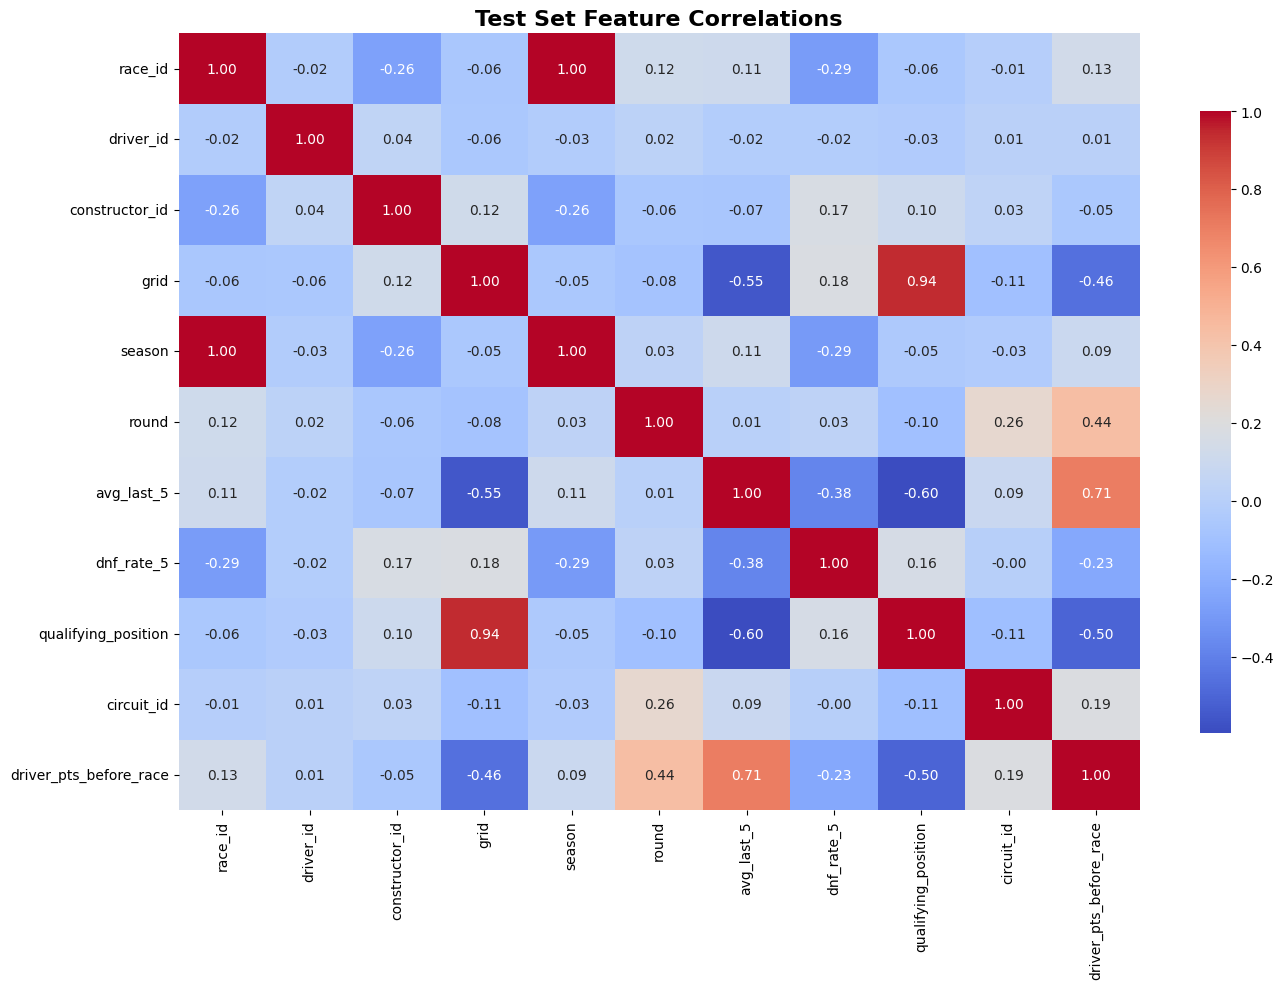

2026-03-04 12:38:57,901 [INFO] root - Predictions vs Actual (First 20 samples)
2026-03-04 12:38:57,903 [INFO] root -     Actual  Predicted
0        1          1
1        0          0
2        0          0
3        0          0
4        1          1
5        0          0
6        0          0
7        1          1
8        1          1
9        1          0
10       0          0
11       0          0
12       0          0
13       1          1
14       0          0
15       0          0
16       1          1
17       0          0
18       1          1
19       0          0
2026-03-04 12:38:57,903 [INFO] root - Note: 1 = Top 10, 0 = Outside Top 10


In [236]:
def plot_correlation_heatmap(data, title="Feature Correlation Matrix"):
    """
    Create and display correlation heatmap for numeric features.
    
    Args:
        data (pd.DataFrame): DataFrame with numeric columns
        title (str): Title for the plot
    """
    plt.figure(figsize=(14, 10))
    corr = data.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'shrink': 0.8})
    plt.title(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_predictions_vs_actual(y_test, y_pred, sample_size=20):
    """
    Display predictions vs actual values for visual inspection.
    
    Args:
        y_test (pd.Series): Actual test target values
        y_pred (np.array): Model predictions
        sample_size (int): Number of samples to display (default: 20)
    """
    comparison_df = pd.DataFrame({
        'Actual': y_test.values[:sample_size],
        'Predicted': y_pred[:sample_size]
    })
    
    logging.info(f"Predictions vs Actual (First {sample_size} samples)")
    logging.info("%s", comparison_df.to_string())
    logging.info("Note: 1 = Top 10, 0 = Outside Top 10")


# Create correlation heatmap
logging.info("Generating correlation heatmap...")
plot_correlation_heatmap(X_test, "Test Set Feature Correlations")

# Display predictions comparison
plot_predictions_vs_actual(y_test, y_pred, sample_size=20)

## Summary

### Pipeline Overview
This cleaned notebook implements a complete machine learning pipeline for predicting F1 race finishing positions:

1. **Data Loading**: Loads all F1 race-related tables from the data source
2. **Feature Engineering**: Creates performance-based features including rolling averages and DNF indicators
3. **Data Merging**: Combines qualifying, standings, and circuit information
4. **Preprocessing**: Encodes categorical variables and handles missing values
5. **Model Training**: Uses Optuna for hyperparameter optimization of XGBClassifier
6. **Evaluation**: Provides comprehensive metrics and feature importance analysis

### Key Improvements over Original
✓ **Modular Design**: Each major task is encapsulated in its own function  
✓ **Documentation**: Comprehensive docstrings explain purpose and parameters  
✓ **Code Comments**: Inline comments explain complex logic  
✓ **Error Handling**: Defensive programming prevents data leakage and errors  
✓ **Reduced Redundancy**: Consolidated repeated code into reusable functions  
✓ **Clear Workflow**: Logical progression from data loading to model evaluation  

### Model Target
**Predicting Top 10 Finishes**: Binary classification model that predicts whether a driver will finish in the top 10 positions during a race.

### Features Used
- `race_id`, `driver_id`, `constructor_id`, `circuit_id`: Encoded IDs
- `grid`: Starting position
- `season`, `round`: Race timing information
- `avg_last_5`: Rolling average points from last 5 races
- `dnf_rate_5`: DNF occurence rate over last 5 races
- `qualifying_position`: Starting position from qualifying

In [237]:
to_predict = dataframes['to_predict']
to_predict.head()


,race_id,driver_id,constructor_id,circuit_id,season,round,grid,qualifying_position,avg_last_5,dnf_rate_5,driver_pts_before_race
0,2024_1,albon,williams,bahrain,2024,1,13,13.0,0.2,0.4,0
1,2024_2,albon,williams,jeddah,2024,2,12,12.0,0.0,0.4,0
2,2024_3,albon,williams,albert_park,2024,3,12,12.0,0.0,0.2,0
3,2024_4,albon,williams,suzuka,2024,4,14,14.0,0.0,0.0,0
4,2024_5,albon,williams,shanghai,2024,5,14,14.0,0.0,0.2,0


In [238]:
to_predict=to_predict.reindex(columns=BASE_FEATURES)
to_predict.head()
to_predict= transform_with_encoders(to_predict, encoders)

In [239]:
to_predict.head()

predictions= final_model.predict(to_predict)

In [240]:
to_predict['top10_predicted'] = predictions   
to_predict = decode_categorical_features(to_predict, encoders)
to_predict.head()

,race_id,driver_id,constructor_id,grid,season,round,avg_last_5,dnf_rate_5,qualifying_position,circuit_id,driver_pts_before_race,top10_predicted
0,2024_1,albon,williams,13,2024,1,0.2,0.4,13.0,bahrain,0,0
1,2024_2,albon,williams,12,2024,2,0.0,0.4,12.0,jeddah,0,0
2,2024_3,albon,williams,12,2024,3,0.0,0.2,12.0,albert_park,0,0
3,2024_4,albon,williams,14,2024,4,0.0,0.0,14.0,suzuka,0,0
4,2024_5,albon,williams,14,2024,5,0.0,0.2,14.0,shanghai,0,0


In [241]:
BATCH_SIZE = 500

def _clean_types(records: list[dict]) -> list[dict]:
    """Convert pandas/numpy types to plain Python types for JSON serialization."""
    cleaned = []
    for record in records:
        clean_row = {}
        for key, value in record.items():
            if isinstance(value, pd.Timestamp):
                clean_row[key] = value.isoformat()
            elif isinstance(value, np.integer):
                clean_row[key] = int(value)
            elif isinstance(value, (np.floating, float)) and (isinstance(value, np.floating) or math.isnan(value)):
                clean_row[key] = None if math.isnan(float(value)) else float(value)
            else:
                clean_row[key] = value
        cleaned.append(clean_row)
    return cleaned


def _clear_table(client: Client, table_name: str) -> None:
    """Delete all rows from a table."""
    client.table(table_name).delete().neq("race_id", " ").execute()


def _insert_batched(client: Client, table_name: str, records: list[dict]) -> int:
    """Insert pre-cleaned records into a table in batches. Returns total rows inserted."""
    total = 0
    for start in range(0, len(records), BATCH_SIZE):
        batch = records[start : start + BATCH_SIZE]
        response = client.table(table_name).insert(batch).execute()
        if response.data:
            total += len(response.data)
    return total


def _prepare_records(df: pd.DataFrame) -> list[dict]:
    """Convert a DataFrame to a clean list of dicts ready for Supabase."""
    df = df.where(pd.notnull(df), other=None)
    return _clean_types(df.to_dict(orient="records"))


def push_table(client: Client, table_name: str, df: pd.DataFrame) -> int:
    """Clear a table and insert fresh data. Returns total rows inserted."""
    _clear_table(client, table_name)
    records = _prepare_records(df)
    return _insert_batched(client, table_name, records)

to_predict= to_predict[['race_id', 'driver_id', 'top10_predicted']]


client = get_supabase_client()
rows = push_table(client, "predictions", to_predict)
logging.info("%d prediction rows upserted to Supabase", rows)

2026-03-04 12:38:57,993 [INFO] __main__ - Connecting to Supabase...
2026-03-04 12:38:58,596 [INFO] httpx - HTTP Request: DELETE https://inispwtbhamelhtpoics.supabase.co/rest/v1/predictions?race_id=neq.+ "HTTP/2 200 OK"
2026-03-04 12:38:58,678 [INFO] httpx - HTTP Request: POST https://inispwtbhamelhtpoics.supabase.co/rest/v1/predictions?columns=%22top10_predicted%22%2C%22race_id%22%2C%22driver_id%22 "HTTP/2 201 Created"
2026-03-04 12:38:58,683 [INFO] root - 200 prediction rows upserted to Supabase


In [242]:

# X_to_push= X[X['season']>=2024].copy()
# print(encoders['driver_id'].classes_)
# final_x=decode_categorical_features(X_to_push, encoders)
# rows= push_table(client, "to_predict", final_x)

# final_x.head()